In [10]:
!python3 -m pip install --break-system-packages seaborn scikit-learn pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 10.2 MB/s  0:00:000.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.6 MB/s  0:00:00 10.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 10.8 MB/s  0:00:01 10.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [seaborn]━━━ 5/6 [seaborn]andas]


Форма данных: (1797, 64)
Количество признаков: 64


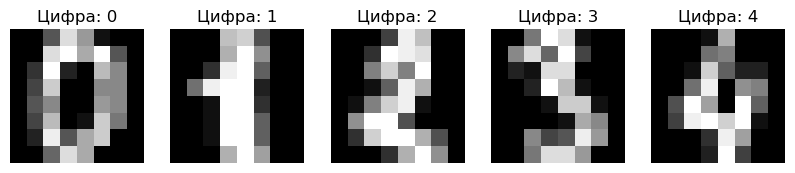

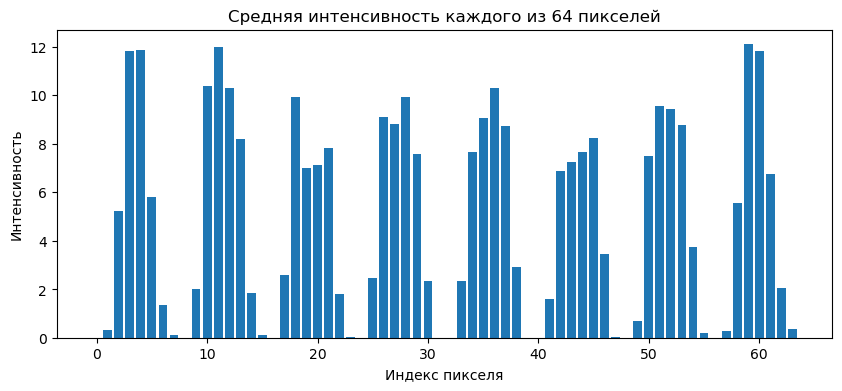

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AffinityPropagation


digits = load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Форма данных: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")

# визуализация нескольких примеров (EDA)
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X[i].reshape(8, 8), cmap='gray')
    plt.title(f"Цифра: {y[i]}")
    plt.axis('off')
plt.show()

# анализ распределения признаков
# посмотрим на средние значения пикселей
plt.figure(figsize=(10, 4))
plt.bar(range(64), X.mean(axis=0))
plt.title("Средняя интенсивность каждого из 64 пикселей")
plt.xlabel("Индекс пикселя")
plt.ylabel("Интенсивность")
plt.show()

In [ ]:
# Гипотеза №1 - Оптимальное количество кластеров для этих данных - 10. (проверено)
# Гипотеза №2 - Из 64 признаков около 10-20% бесполезны. (проверено)
# Гипотеза №3 - Алгоритмы будут чаще всего ошибаться на парах (1 и 7), (3 и 8) или (5 и 6). (не проверена)

In [38]:
class MyKMeans:
    def __init__(self, n_clusters=10, max_iter=300, tol=1e-4):
        self.n_clusters = n_clusters # сколько групп хотим найти
        self.max_iter = max_iter     # максимум попыток сдвинуть центры
        self.tol = tol               # порог: если центры сдвинулись меньше чем на это число — мы закончили
        
    def fit(self, X):
        # берем случайные точки из данных как первые центры
        np.random.seed(42) 
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx]
        
        for i in range(self.max_iter):
            # cчитаем расстояние от каждой точки до каждого центра
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels_ = np.argmin(distances, axis=1)
            new_centroids = np.array([X[self.labels_ == k].mean(axis=0) for k in range(self.n_clusters)])
            
            # если центры почти не сдвинулись, выходим из цикла раньше времени
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break
            self.centroids = new_centroids
        return self

    def predict(self, X):
        # для новых данных просто находим ближайший из обученных центров
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

def get_metrics(name, model, data):
    start = time.time()
    # обучаем и получаем метки кластеров
    if hasattr(model, 'fit_predict'):
        labels = model.fit_predict(data)
    else:
        model.fit(data)
        labels = model.labels_
    t = time.time() - start
    
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters_ < 2:
        return {"Model": name, "Time": t, "Silhouette": -1, "Clusters": n_clusters_}
    
    sil = silhouette_score(data, labels)
    return {"Model": name, "Time": t, "Silhouette": sil, "Clusters": n_clusters_}

comparison_results = []

# n_clusters фиксируем на основе знаний о датасете
comparison_results.append(get_metrics("MyKMeans", MyKMeans(n_clusters=10), X_scaled))
comparison_results.append(get_metrics("Affinity Propagation", AffinityPropagation(damping=0.9, random_state=42), X_scaled))
comparison_results.append(get_metrics("Sklearn KMeans", KMeans(n_clusters=10, n_init=10), X_scaled))

# DBSCAN с подбором гиперпараметра eps (радиус поиска соседей)
for eps_val in [3.5, 4.0, 4.5, 5.0, 5.5]:
    comparison_results.append(get_metrics(f"DBSCAN (eps={eps_val})", DBSCAN(eps=eps_val), X_scaled))

df_compare = pd.DataFrame(comparison_results)
print(df_compare)

                  Model      Time  Silhouette  Clusters
0              MyKMeans  0.060007    0.125213        10
1  Affinity Propagation  2.053532    0.105500       131
2        Sklearn KMeans  0.053167    0.147180        10
3      DBSCAN (eps=3.5)  0.003895   -0.186586        26
4      DBSCAN (eps=4.0)  0.004447   -0.058726        26
5      DBSCAN (eps=4.5)  0.004904   -0.060243        12
6      DBSCAN (eps=5.0)  0.004242   -0.009436         4
7      DBSCAN (eps=5.5)  0.004651    0.003910         3


In [39]:
# Подбор гиперпараметров и повторное сравнение

"""
Будем использовать несколько метрик:
1. Silhoutte - (-1 - точка илеально находится в своем кластере, 0 - прямо на границу, -1 - ближе к соседнему чем к своему)
2. Adjusted Rand Index - если в реальности две точки принадлежат одной цифре, и алгоритм тоже положил их в один кластер — это плюс. Если в реальности они разные, а алгоритм положил в один — это минус.
3. David-Bouldin Index - соотношение разброса внутри кластеров к расстоянию между ними. (чем меньше тем лучше)
"""

from sklearn.metrics import davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

def get_full_metrics(name, labels, data, true_labels, exec_time):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters < 2:
        return {"Model": name, "Clusters": n_clusters, "Time": exec_time, "Silhouette": -1, "DBI": -1, "ARI": -1}
    
    sil = silhouette_score(data, labels)
    dbi = davies_bouldin_score(data, labels)
    ari = adjusted_rand_score(true_labels, labels)
    
    return {
        "Model": name, 
        "Clusters": n_clusters, 
        "Time": f"{exec_time:.4f}", 
        "Silhouette": round(sil, 4), 
        "DBI": round(dbi, 4), # Дэвиса-Болдина
        "ARI": round(ari, 4)  # насколько совпало с реальностью
    }

best_dbscan_score = -1
best_dbscan_params = None

print("Тюнинг DBSCAN...")
for eps in [4.0, 4.5, 5.0, 5.5]:
    for min_samples in [3, 5, 10]:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_
        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan_params = (eps, min_samples)

print(f"Лучшие параметры DBSCAN: eps={best_dbscan_params[0]}, min_samples={best_dbscan_params[1]}")

best_agg_score = -1
best_linkage = None

for linkage in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=10, linkage=linkage).fit(X_scaled)
    score = silhouette_score(X_scaled, agg.labels_)
    if score > best_agg_score:
        best_agg_score = score
        best_linkage = linkage

print(f"Лучший тип связи для Agglomerative: {best_linkage}")

final_results = []

# MyKmeans
start = time.time()
my_km = MyKMeans(n_clusters=10).fit(X_scaled)
final_results.append(get_full_metrics("MyKMeans (default)", my_km.labels_, X_scaled, y, time.time()-start))

# 2. Sklearn KMeans (без тюнинга - стандартные 10 итераций)
start = time.time()
sk_km_nt = KMeans(n_clusters=10, n_init=10).fit(X_scaled) # Поправил скобки и добавил .fit()
final_results.append(get_full_metrics("Sklearn KMeans (not tuned)", sk_km_nt.labels_, X_scaled, y, time.time()-start))

# 3. Sklearn KMeans (с тюнингом - больше итераций и фиксация рандома)
start = time.time()
sk_km_t = KMeans(n_clusters=10, n_init=20, random_state=42).fit(X_scaled)
final_results.append(get_full_metrics("Sklearn KMeans (tuned)", sk_km_t.labels_, X_scaled, y, time.time()-start))

# 4. DBSCAN (фиксированный eps, который мы пробовали раньше)
start = time.time()
db_nt = DBSCAN(eps=4.5).fit(X_scaled) 
final_results.append(get_full_metrics("DBSCAN (not tuned - 4.5 eps)", db_nt.labels_, X_scaled, y, time.time()-start))

# 5. DBSCAN (лучший из твоего поиска по сетке)
start = time.time()
db_t = DBSCAN(eps=best_dbscan_params[0], min_samples=best_dbscan_params[1]).fit(X_scaled)
final_results.append(get_full_metrics("DBSCAN (tuned)", db_t.labels_, X_scaled, y, time.time()-start))

# 6. Agglomerative (стандартный - обычно linkage='ward')
start = time.time()
agg_nt = AgglomerativeClustering(n_clusters=10).fit(X_scaled)
final_results.append(get_full_metrics("Agglomerative (not tuned)", agg_nt.labels_, X_scaled, y, time.time()-start))

# 7. Agglomerative (с лучшим типом связи из твоего поиска)
start = time.time()
agg_t = AgglomerativeClustering(n_clusters=10, linkage=best_linkage).fit(X_scaled)
final_results.append(get_full_metrics("Agglomerative (tuned)", agg_t.labels_, X_scaled, y, time.time()-start))

df_final = pd.DataFrame(final_results)
display(df_final)

Тюнинг DBSCAN...
Лучшие параметры DBSCAN: eps=5.5, min_samples=3
Лучший тип связи для Agglomerative: average


,Model,Clusters,Time,Silhouette,DBI,ARI
0,MyKMeans (default),10,0.0373,0.1252,1.9067,0.4575
1,Sklearn KMeans (not tuned),10,0.0554,0.1472,1.8982,0.4622
2,Sklearn KMeans (tuned),10,0.1047,0.1423,1.8862,0.4780
3,DBSCAN (not tuned - 4.5 eps),12,0.0045,-0.0602,2.6063,0.1822
4,DBSCAN (tuned),3,0.0045,0.2435,3.1746,0.0007
5,Agglomerative (not tuned),10,0.0426,0.1253,1.9672,0.6643
6,Agglomerative (tuned),10,0.0411,0.5317,0.4405,0.0000


Расчет методом локтя и силуэта для разных K...


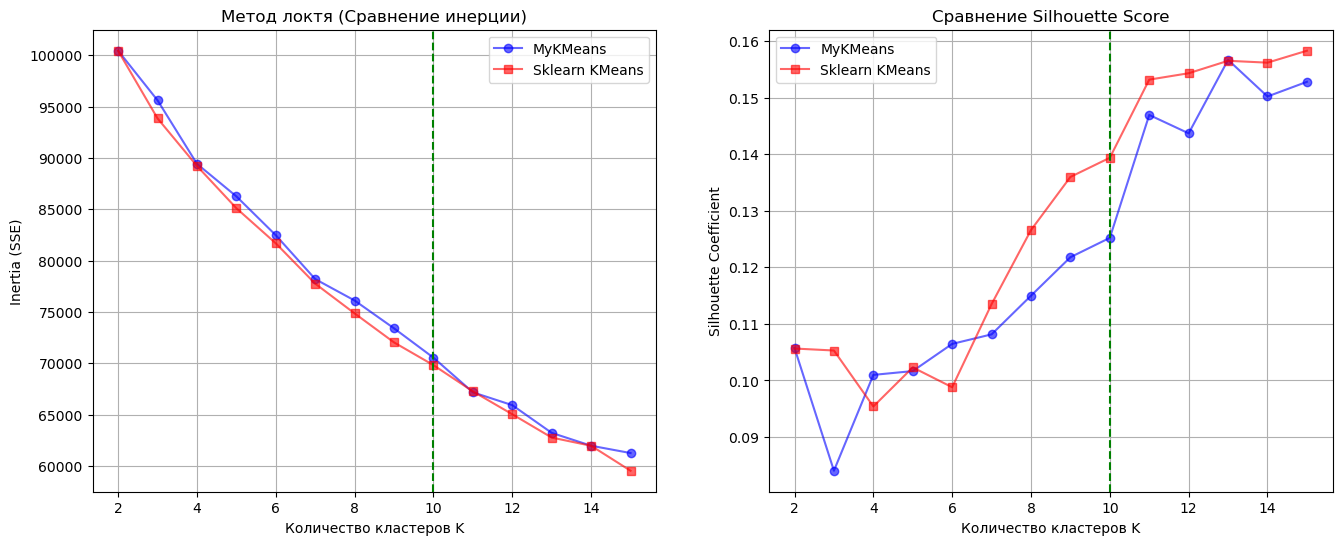

In [44]:
# Cтандартная иерархическая кластеризация показала лучший результат по совпадению с реальными цифрами (ARI почти 0.67)
# Алгоритм Ward (стандартный для Agglomerative) очень хорошо умеет находить компактные кучки. Для цифр это сработало лучше, чем K-Means.

# В Sklearn тюнинг (увеличение n_init) поднял ARI до 0.478. Это доказывает, что чем больше попыток делает алгоритм, тем точнее он находит «истинные» центры цифр.

# DBSCAN оказался неприменим к данным высокой размерности (это подтверждает его Adjusted Rand Index). 
# Из-за разреженности пространства алгоритм либо выделяет слишком много мелких групп с отрицательным силуэтом, 
# либо объединяет все цифры в 3-4 гигантских кластера при увеличении радиуса поиска (eps)

# В целом можно заметить что реализация kmeans из sklearn примерно сходится с собственной реализацей.
# Судя по данным DBI - оба подхода "собрали" довольно компактные кластеры.
# По сравнению с другими алгоритмами - знание о 10 классах позволяет игнорировать мелкий шум и фокусироваться на главных различиях в форме цифр
# Для более детального анализа - рассмотрим значения по методу локтя для обоих вариантов + силуэты


k_range = range(2, 16)
my_inertia = []
sk_inertia = []
my_silhouette = []
sk_silhouette = []

print("Расчет методом локтя и силуэта для разных K...")

for k in k_range:
    my_km = MyKMeans(n_clusters=k).fit(X_scaled)
    dist = np.linalg.norm(X_scaled[:, np.newaxis] - my_km.centroids, axis=2)
    inertia = np.sum(np.min(dist, axis=1)**2)
    my_inertia.append(inertia)
    my_silhouette.append(silhouette_score(X_scaled, my_km.labels_))
    
    sk_km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    sk_inertia.append(sk_km.inertia_)
    sk_silhouette.append(silhouette_score(X_scaled, sk_km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# метода локтя
ax1.plot(k_range, my_inertia, marker='o', label='MyKMeans', color='blue', alpha=0.6)
ax1.plot(k_range, sk_inertia, marker='s', label='Sklearn KMeans', color='red', alpha=0.6)
ax1.set_title("Метод локтя (Сравнение инерции)")
ax1.set_xlabel("Количество кластеров K")
ax1.set_ylabel("Inertia (SSE)")
ax1.axvline(x=10, color='green', linestyle='--')
ax1.legend()
ax1.grid(True)

# силуэт
ax2.plot(k_range, my_silhouette, marker='o', label='MyKMeans', color='blue', alpha=0.6)
ax2.plot(k_range, sk_silhouette, marker='s', label='Sklearn KMeans', color='red', alpha=0.6)
ax2.set_title("Сравнение Silhouette Score")
ax2.set_xlabel("Количество кластеров K")
ax2.set_ylabel("Silhouette Coefficient")
ax2.axvline(x=10, color='green', linestyle='--')
ax2.legend()
ax2.grid(True)

plt.show()

Запускаю t-SNE, подожди немного...


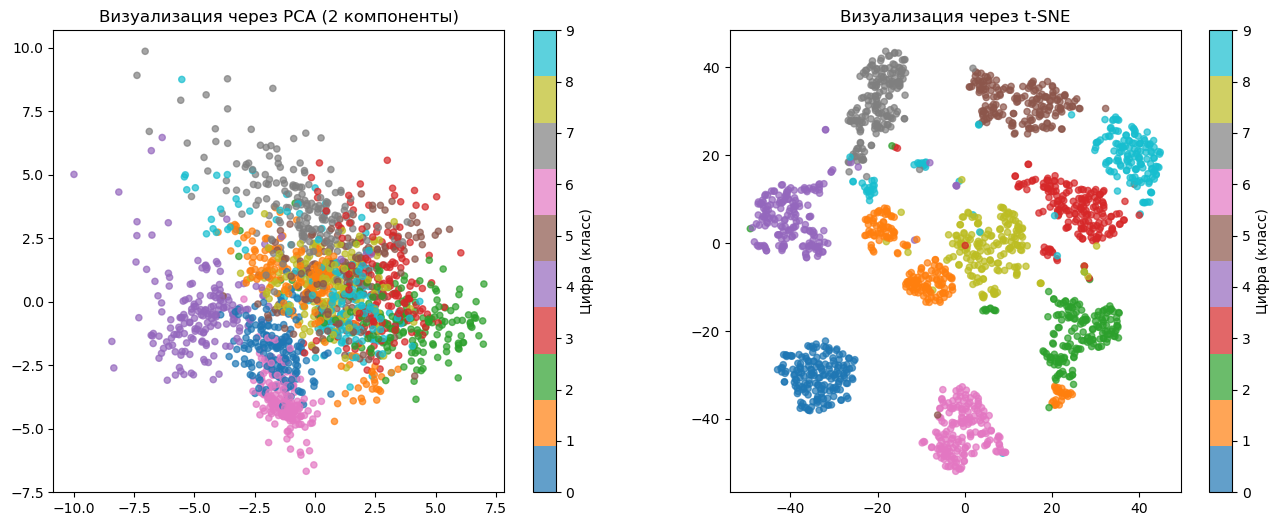

In [41]:
# 1. PCA до 2-х компонент
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 2. t-SNE до 2-х компонент (это может занять 10-20 секунд)
print("Запускаю t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_2d = tsne.fit_transform(X_scaled)

# Отрисовка
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График PCA
scatter1 = ax1.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', alpha=0.7, s=20)
ax1.set_title("Визуализация через PCA (2 компоненты)")
plt.colorbar(scatter1, ax=ax1, label='Цифра (класс)')

# График t-SNE
scatter2 = ax2.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y, cmap='tab10', alpha=0.7, s=20)
ax2.set_title("Визуализация через t-SNE")
plt.colorbar(scatter2, ax=ax2, label='Цифра (класс)')

plt.show()

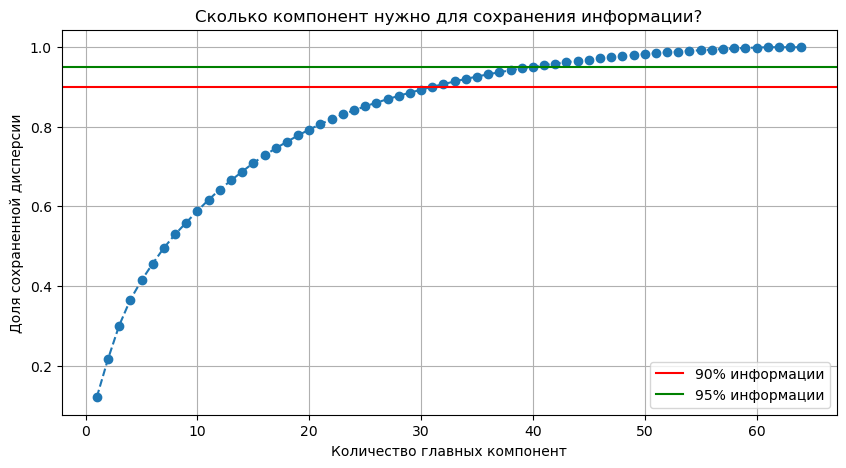

Для 90% информации нужно 31 компонент.
Для 95% информации нужно 40 компонент.


In [42]:
# При снижении размерности до 2-х - визуально получаем слишкмо "кучные" кластеры, попробуем подойти к этому более ответсвенности и посмотреть на различные итоговые размерности.
# Проанализируем кол-во компонент для сжатия (по методу накопленной дисперсии)

pca_full = PCA().fit(X_scaled)

# считаем накопленную сумму объясненной дисперсии
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 65), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% информации')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% информации')

# найдем точные числа для отчета
n_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
n_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1

plt.title("Сколько компонент нужно для сохранения информации?")
plt.xlabel("Количество главных компонент")
plt.ylabel("Доля сохраненной дисперсии")
plt.legend()
plt.grid(True)
plt.show()

print(f"Для 90% информации нужно {n_90} компонент.")
print(f"Для 95% информации нужно {n_95} компонент.")

Запускаю PCA-анализ...


,n_components,Info_Preserved (%),Silhouette,ARI,DBI,Time
0,2,21.59,0.3778,0.3259,0.7822,0.0749
1,5,41.40,0.3092,0.4224,1.0101,0.0443
2,10,58.87,0.2732,0.4831,1.2480,0.0440
3,20,79.31,0.1960,0.3970,1.4533,0.0679
4,30,89.32,0.1751,0.4764,1.7082,0.0505
5,40,95.08,0.1595,0.5694,1.7701,0.0525
6,50,98.28,0.1510,0.4708,1.8647,0.0528
7,64,100.00,0.1394,0.5344,1.8770,0.0564


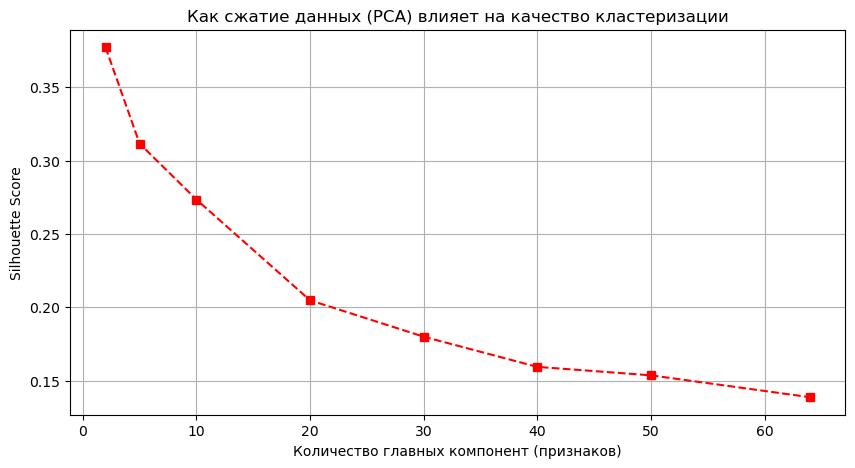

In [43]:
components = [2, 5, 10, 20, 30, 40, 50, 64]
pca_full_impact = []

print("Запускаю PCA-анализ...")

for n in components:
    pca = PCA(n_components=n)
    X_reduced = pca.fit_transform(X_scaled)
    
    # сколько информации (дисперсии) сохранили (в процентах)
    info_preserved = np.sum(pca.explained_variance_ratio_) * 100
    
    start = time.time()
    model = KMeans(n_clusters=10, n_init=10, random_state=42).fit(X_reduced)
    exec_time = time.time() - start
    
    res = get_full_metrics(f"PCA_{n}", model.labels_, X_reduced, y, exec_time)
    
    res['n_components'] = n
    res['Info_Preserved (%)'] = round(info_preserved, 2)
    
    pca_full_impact.append(res)

df_pca_final = pd.DataFrame(pca_full_impact)

cols = ['n_components', 'Info_Preserved (%)', 'Silhouette', 'ARI', 'DBI', 'Time']
display(df_pca_final[cols])

df_pca = pd.DataFrame(pca_impact)

plt.figure(figsize=(10, 5))
plt.plot(df_pca['n_features'], df_pca['Silhouette'], marker='s', color='red', linestyle='--')
plt.title("Как сжатие данных (PCA) влияет на качество кластеризации")
plt.xlabel("Количество главных компонент (признаков)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [ ]:
# При сильном сжатии (2-10 компонент) мы сохраняем мало информации (21-58%). 
# Данные превращаются в очень плотные, красивые «кучки» (поэтому Силуэт высокий), но эти кучки не соответствуют реальным цифрам. 
# Мы просто «сплющили» разные цифры в одну кучу.

# На 40 компонентах показатель ARI достигает пика — 0.5694.  Мы сохранили 95.08% информации (при этом сократив объем данных на 37%). Этого достаточно, чтобы алгоритм максимально точно (насколько он может) отличил одну цифру от другой.

# Когда мы добавляем последние 14-24 признака, ARI начинает падать (с 0.56 до 0.53), а Silhouette становится совсем низким (0.13).
# Последние компоненты несут всего 2-5% информации. Обычно это случайные шумы или мелкие детали, которые только запутывают K-Means. Расстояния между точками в 64-мерном пространстве становятся слишком большими и неинформативными.
